# Uniqueness of festival lineups

This notebook compares the similarity of a given festival's lineup with those of other festivals.

Similarity is computed using the [Jaccard Similarity Index](https://www.ibm.com/think/topics/jaccard-similarity), which measures how many elements (artists) are shared between two sets (lineups), normalized to their size. A Jaccard similarity of 0 means there is are no shared elements, and 1 means a full match between the two sets.

In [1]:
import re
import pandas as pd
from festival_analysis.analysis_utils import query_db, jaccard_similarity
from itertools import combinations, zip_longest
import seaborn as sns
from matplotlib import pyplot as plt
from tabulate import tabulate

pd.options.display.float_format = "{:,.2f}".format

## Data pull

In [2]:
query_lineups = """
SELECT
  festival_id||'-'||edition_year||'-'||artist_id AS entry_id,
  CAST(festival_id AS VARCHAR) AS festival_id,
  festival_id||'-'||edition_year AS edition_id,
  festival_name,
  size_band,
  edition_year,
  location_country,
  CAST(artist_id AS VARCHAR) AS artist_id,
  display_name,
  artist_country,
  ra_status
FROM
  edition_lineups
-- Look onwards from 2015 without lockdown years
WHERE 
  edition_year >= 2015 
  AND edition_year NOT IN (2020, 2021)
"""

df_lineups = query_db(query_lineups, index="entry_id")

In [3]:
df_lineups.head()

,festival_id,edition_id,festival_name,size_band,edition_year,location_country,artist_id,display_name,artist_country,ra_status
entry_id,,,,,,,,,,
6444672821443970373-2019-6058557091064623724,6444672821443970373,6444672821443970373-2019,Animal Crossing,2 - S,2019,GB,6058557091064623724,SIT Amphia,RO,REGIONAL
2226532901355631485-2022-64353276929404461,2226532901355631485,2226532901355631485-2022,Festifest,4 - L,2022,NL,64353276929404461,Mike Sacchetti,VE,REGIONAL
1311579144894607994-2017-2174457907548606988,1311579144894607994,1311579144894607994-2017,Baltic Weekender,2 - S,2017,GB,2174457907548606988,Melé,GB,REGIONAL
2648629204636342015-2023-3656691846302276550,2648629204636342015,2648629204636342015-2023,DGTL,4 - L,2023,NL,3656691846302276550,Valentina Luz,BR,REGIONAL
1457418356257237432-2025-3736882595637923420,1457418356257237432,1457418356257237432-2025,De Weide,1 - XS,2025,NL,3736882595637923420,ESHU,NL,REGIONAL


## Housekeeping

Create mappings and functions to make later analysis easy and tidy.

In [4]:
df_festival_stats = df_lineups.groupby("festival_id").agg(
    {
        "festival_name": pd.Series.mode,
        "size_band": pd.Series.mode,
        "location_country": pd.Series.mode,
    }
)
df_festival_stats

,festival_name,size_band,location_country
festival_id,,,
1082689011160469009,Naturalis,1 - XS,IT
1199349725585256505,Botanica,1 - XS,SE
1311579144894607994,Baltic Weekender,2 - S,GB
1336484889209428545,Accidental Meetings,1 - XS,GB
1457418356257237432,De Weide,1 - XS,NL
...,...,...,...
8868442761932147185,Lentekabinet,2 - S,NL
8969544748426605587,Lighthouse,2 - S,HR
8982369933757010704,Horst,3 - M,BE


In [5]:
festival_name_map = df_festival_stats["festival_name"].to_dict()
festival_id_map = {v: k for k, v in festival_name_map.items()}
artist_name_map = (
    df_lineups[["artist_id", "display_name"]]
    .set_index("artist_id")["display_name"]
    .to_dict()
)

In [6]:
n_festivals = 50
top_n_festivals = (
    df_lineups.groupby("festival_id")
    .size()
    .sort_values(ascending=False)[:n_festivals]
    .index
)

In [7]:
n_artists = 500
top_n_artists = (
    df_lineups.groupby("artist_id")
    .size()
    .sort_values(ascending=False)[:n_artists]
    .index
)

In [8]:
def festival_similarity(fid1: str, fid2: str, df_lineups: pd.DataFrame) -> tuple:
    """
    Compute the Jaccard similarity of two festivals 
    (deduped list of all artists playing across every edition of each festival).
    """
    artists1 = set(df_lineups[df_lineups["festival_id"] == fid1]["artist_id"])
    artists2 = set(df_lineups[df_lineups["festival_id"] == fid2]["artist_id"])
    jaccard = jaccard_similarity(artists1, artists2)
    return (fid1, fid2, jaccard)


def build_df_festival_similarities(
    df_lineups: pd.DataFrame, df_festival_stats: pd.DataFrame
) -> pd.DataFrame:
    """Create a matrix of all festival similarities."""
    festival_pairs = combinations(df_lineups["festival_id"].unique(), 2)
    similarity_results = [
        festival_similarity(fid1, fid2, df_lineups=df_lineups)
        for fid1, fid2 in festival_pairs
    ]
    df_similarities = pd.DataFrame(
        similarity_results,
        columns=["festival_id1", "festival_id2", "jaccard_similarity"],
    )
    df_similarities = df_similarities.merge(
        df_festival_stats.add_suffix("1"),
        how="left",
        left_on="festival_id1",
        right_index=True,
    )
    df_similarities = df_similarities.merge(
        df_festival_stats.add_suffix("2"),
        how="left",
        left_on="festival_id2",
        right_index=True,
    )
    return df_similarities


def festival_edition_similarity(
    fe_id1: str, fe_id2: str, df_lineups: pd.DataFrame
) -> tuple:
    """Compute the Jaccard similarity of two festival editions."""
    artists1 = set(df_lineups[df_lineups["edition_id"] == fe_id1]["artist_id"])
    artists2 = set(df_lineups[df_lineups["edition_id"] == fe_id2]["artist_id"])
    jaccard = jaccard_similarity(artists1, artists2)
    return (fe_id1, fe_id2, jaccard)


def build_df_festival_edition_similarities(
    df_lineups: pd.DataFrame, df_festival_stats: pd.DataFrame, edition_year: int
) -> pd.DataFrame:
    """Create a matrix of festival edition similarities within a single year."""
    df_editions = df_lineups[df_lineups['edition_year'] == edition_year]
    edition_pairs = combinations(df_editions["edition_id"].unique(), 2)
    similarity_results = [
        festival_edition_similarity(fid1, fid2, df_lineups=df_editions)
        for fid1, fid2 in edition_pairs
    ]
    df_similarities = pd.DataFrame(
        similarity_results,
        columns=["edition_id1", "edition_id2", "jaccard_similarity"],
    )
    df_similarities['festival_id1'] = df_similarities['edition_id1'].str[:-5]
    df_similarities['festival_id2'] = df_similarities['edition_id2'].str[:-5]
    df_similarities['edition_year'] = df_similarities['edition_id1'].str[-4:].astype(int)
    df_similarities = df_similarities.merge(
        df_festival_stats.add_suffix("1"),
        how="left",
        left_on="festival_id1",
        right_index=True,
    )
    df_similarities = df_similarities.merge(
        df_festival_stats.add_suffix("2"),
        how="left",
        left_on="festival_id2",
        right_index=True,
    )
    return df_similarities


def show_similarity(
    id1: str,
    id2: str,
    df_lineups: pd.DataFrame,
    festival_name_map: dict,
    artist_name_map: dict,
) -> None:
    """Print a summary of the similarity of either:
    - two festivals (every edition of each)
    - two festival editions

    This split is inferred from the ending of each ID (edition IDs end with a year e.g. "-2016").
    """
    id1_is_edition = re.search(r"-\d{4}$", id1)
    id2_is_edition = re.search(r"-\d{4}$", id2)

    if id1_is_edition and id2_is_edition:
        id_col = "edition_id"
        name1 = f"{festival_name_map[id1[:-5]]}-{id1[-4:]}"
        name2 = f"{festival_name_map[id2[:-5]]}-{id2[-4:]}"
        similarity_function = festival_edition_similarity
    elif not id1_is_edition and not id2_is_edition:
        id_col = "festival_id"
        name1 = festival_name_map[id1]
        name2 = festival_name_map[id2]
        similarity_function = festival_similarity
    else:
        raise ValueError(
            "Both given IDs must be either editions or festivals, no mixing."
        )

    artists_1 = set(df_lineups[df_lineups[id_col] == id1]["artist_id"])
    artists_2 = set(df_lineups[df_lineups[id_col] == id2]["artist_id"])

    intersection = artists_1.intersection(artists_2)
    only1 = artists_1.difference(artists_2)
    only2 = artists_2.difference(artists_1)
    jaccard_similarity = similarity_function(id1, id2, df_lineups)[2]

    print(f"Similarity report between {id1} - {name1} and {id2} - {name2}")
    print(f"Jaccard similarity: {jaccard_similarity:.2f}")
    print(
        f"{len(intersection)} artists playing at both, {len(only1)} playing only at {name1}, {len(only2)} playing only at {name2}"
    )
    table = list(
        zip_longest(
            [artist_name_map[aid] for aid in intersection],
            [artist_name_map[aid] for aid in only1],
            [artist_name_map[aid] for aid in only2],
            fillvalue="",
        )
    )
    print(
        tabulate(
            table,
            headers=[
                "Intersection",
                f"Playing only at {name1}",
                f"Playing only at {name2}",
            ],
        )
    )

## Analysis

### Festival level

In [9]:
# Save time by just computing similarities across the top few hundred artists
df_lineups = df_lineups[df_lineups["artist_id"].isin(top_n_artists)]

In [10]:
# Create matrix of similarities across all festivals.
df_similarities = build_df_festival_similarities(
    df_lineups=df_lineups, df_festival_stats=df_festival_stats
)

What does the similarity look like across the entire dataset of ~140 festivals?

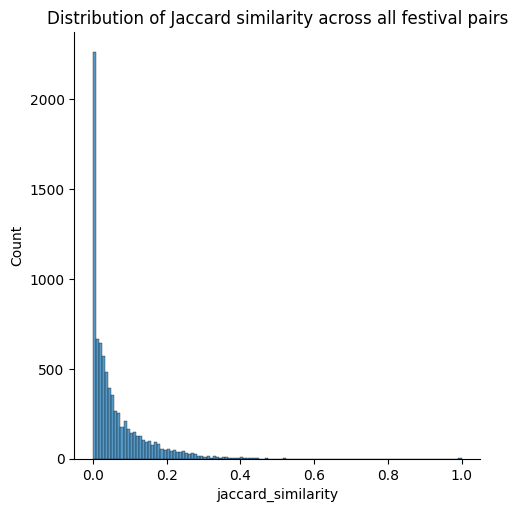

In [11]:
sns.displot(df_similarities["jaccard_similarity"])
plt.title("Distribution of Jaccard similarity across all festival pairs")
plt.show()

In [12]:
mean_similarities = df_similarities.groupby("festival_id1")["jaccard_similarity"].mean()
print(f"Average Jaccard similarity: {mean_similarities.mean():.2f}")

Average Jaccard similarity: 0.04


In general, festivals are pretty unique across the whole dataset. What if we filter for big festivals only?

In [13]:
df_similarities_top_n_festivals = df_similarities[
    (df_similarities["festival_id1"].isin(top_n_festivals))
    & (df_similarities["festival_id2"].isin(top_n_festivals))
]

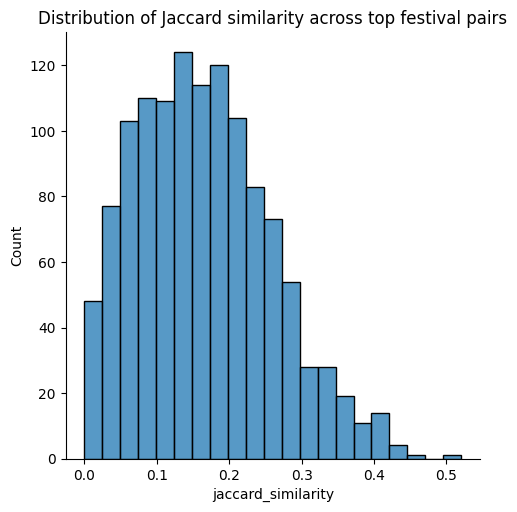

In [14]:
sns.displot(df_similarities_top_n_festivals["jaccard_similarity"])
plt.title("Distribution of Jaccard similarity across top festival pairs")
plt.show()

In [15]:
mean_similarities = df_similarities_top_n_festivals.groupby("festival_id1")[
    "jaccard_similarity"
].mean()
print(f"Average Jaccard similarity: {mean_similarities.mean():.2f}")

Average Jaccard similarity: 0.15


Sharp increase in average Jaccard similarity when filtering for larger festivals.
Let's look at some individual examples. 

In [16]:
df_similarities_top_n_festivals.sort_values("jaccard_similarity", ascending=False).head(
    30
)[["festival_name1", "festival_name2", "jaccard_similarity"]]

,festival_name1,festival_name2,jaccard_similarity
3948,Dekmantel,Draaimolen,0.52
4245,Dimensions,Houghton,0.45
4979,Love International,Gala,0.44
387,Brunch Electronik,DGTL,0.43
1481,Horst,Dekmantel,0.43
3944,Dekmantel,Dimensions,0.42
1466,Horst,Soundit,0.42
3380,Drift,Dekmantel,0.42
1595,DGTL,Dekmantel,0.41
1287,Gottwood,Houghton,0.41


In [17]:
show_similarity(
    festival_id_map["Horst"],
    festival_id_map["Dekmantel"],
    df_lineups=df_lineups,
    festival_name_map=festival_name_map,
    artist_name_map=artist_name_map,
)

Similarity report between 8982369933757010704 - Horst and 8578965883151947907 - Dekmantel
Jaccard similarity: 0.43
139 artists playing at both, 65 playing only at Horst, 119 playing only at Dekmantel
Intersection              Playing only at Horst    Playing only at Dekmantel
------------------------  -----------------------  ---------------------------
Four Tet                  dj sweet6teen            Jon Hopkins
Tama Sumo                 Cassy                    Octave One
Motor City Drum Ensemble  Tai Lokun                Dekmantel Soundsystem
DJ Python                 Narciss                  Nina Kraviz
Or:la                     Jonny Rock               Blasha & Allatt
BADSISTA                  Manfredas                Andrew Weatherall
Shackleton                Angel D'lite             Karenn
Surgeon                   Lola Haro                The Hacker
Midland                   Unai Trotti              DAX J
John Talabot              Mor Elian                Kamma
Young Marco  

In [18]:
show_similarity(
    festival_id_map["Houghton"],
    festival_id_map["Gottwood"],
    df_lineups=df_lineups,
    festival_name_map=festival_name_map,
    artist_name_map=artist_name_map,
)

Similarity report between 3602738408784743846 - Houghton and 5837716347545413629 - Gottwood
Jaccard similarity: 0.41
105 artists playing at both, 61 playing only at Houghton, 91 playing only at Gottwood
Intersection         Playing only at Houghton    Playing only at Gottwood
-------------------  --------------------------  --------------------------
Cassy                Tasha                       Yushh
Kyle Toole           DJ Stingray 313             Mor Elian
Tama Sumo            Grace Sands                 Motor City Drum Ensemble
Man Power            Four Tet                    Laurine
Andrew Weatherall    Objekt                      Heels & Souls
Shackleton           Jen Cardini                 Young Marco
Luke Una             Fadi Mohem                  Tornado Wallace
Midland              Polygonia                   Blawan
John Talabot         Budino                      Enzo Siragusa
XDB                  Or:la                       Dan Shake
Chez de Milo         Peverelist    

In [19]:
show_similarity(
    festival_id_map["Gala"] + "-2026",
    festival_id_map["Lentekabinet"] + "-2026",
    df_lineups=df_lineups,
    festival_name_map=festival_name_map,
    artist_name_map=artist_name_map,
)

Similarity report between 2919907375839432406-2026 - Gala-2026 and 8868442761932147185-2026 - Lentekabinet-2026
Jaccard similarity: 0.17
14 artists playing at both, 49 playing only at Gala-2026, 17 playing only at Lentekabinet-2026
Intersection      Playing only at Gala-2026    Playing only at Lentekabinet-2026
----------------  ---------------------------  -----------------------------------
Peach             Christian AB                 Gabrielle Kwarteng
Surusinghe        Kia (AU)                     Honey Dijon
Call Super        Tasha                        Identified Patient
Hunee             dj sweet6teen                Young Marco
Sedef Adasï       Cassy                        Suze Ijó
Saoirse           Tai Lokun                    Elias Mazian
CCL               Objekt                       Ineffekt
Prosumer          Jonny Rock                   Goldie
Moxie             Amaliah                      Samuel Deep
Job Jobse         Paranoid London              Shanti Celeste
Seth Tr

### Edition level

Has similarity increased over time?

Ideal output:
- Scatter chart showing similarity index of festival editions against editions of other festivals in same year
- Line chart of average similarity index per edition-year

Both need to start with a list of similarity matrices per year

In [20]:
df_lineups = df_lineups[
    (df_lineups['festival_id'].isin(top_n_festivals)) 
    & (df_lineups['artist_id'].isin(top_n_artists))
]

In [21]:
years = sorted(df_lineups['edition_year'].unique())
dfs_similarities = [
    build_df_festival_edition_similarities(
        df_lineups=df_lineups, df_festival_stats=df_festival_stats, edition_year=year
    ) for year in years
]
df_similarities = pd.concat(dfs_similarities)

In [22]:
df_similarities

,edition_id1,edition_id2,jaccard_similarity,festival_id1,festival_id2,edition_year,festival_name1,size_band1,location_country1,festival_name2,size_band2,location_country2
0,5036496510386399279-2015,7626362375975140841-2015,0.03,5036496510386399279,7626362375975140841,2015,PollerWiesen,3 - M,DE,Freerotation,1 - XS,GB
1,5036496510386399279-2015,7724374054458662452-2015,0.02,5036496510386399279,7724374054458662452,2015,PollerWiesen,3 - M,DE,Dimensions,2 - S,HR
2,5036496510386399279-2015,648959496124676712-2015,0.00,5036496510386399279,648959496124676712,2015,PollerWiesen,3 - M,DE,Love International,2 - S,HR
3,5036496510386399279-2015,5635464652128728794-2015,0.04,5036496510386399279,5635464652128728794,2015,PollerWiesen,3 - M,DE,Field Maneuvers,1 - XS,GB
4,5036496510386399279-2015,7139381419273560989-2015,0.04,5036496510386399279,7139381419273560989,2015,PollerWiesen,3 - M,DE,Draaimolen,2 - S,NL
...,...,...,...,...,...,...,...,...,...,...,...,...
941,7043969437698312234-2026,4055810461483921623-2026,0.05,7043969437698312234,4055810461483921623,2026,Junction 2,3 - M,GB,Brunch Electronik,4 - L,ES
942,7043969437698312234-2026,5248125261073838480-2026,0.00,7043969437698312234,5248125261073838480,2026,Junction 2,3 - M,GB,Paradigm,3 - M,NL
943,4338806641977936723-2026,4055810461483921623-2026,0.09,4338806641977936723,4055810461483921623,2026,Mint Festival,2 - S,GB,Brunch Electronik,4 - L,ES
944,4338806641977936723-2026,5248125261073838480-2026,0.00,4338806641977936723,5248125261073838480,2026,Mint Festival,2 - S,GB,Paradigm,3 - M,NL


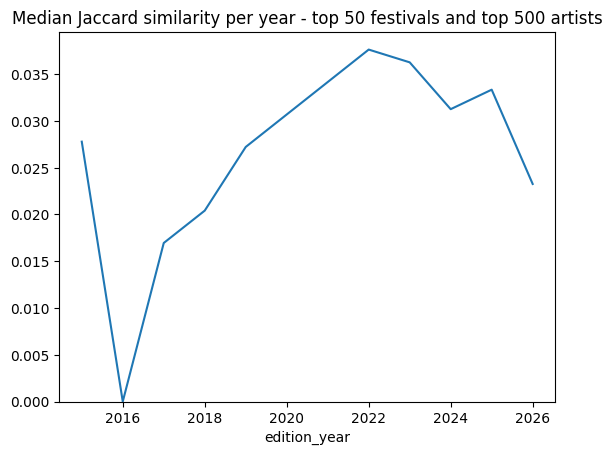

In [23]:
mean_similarities = df_similarities.groupby('edition_year')['jaccard_similarity'].median()
mean_similarities.plot(kind='line', title='Median Jaccard similarity per year - top 50 festivals and top 500 artists')
plt.gca().set_ylim(0)
plt.show()

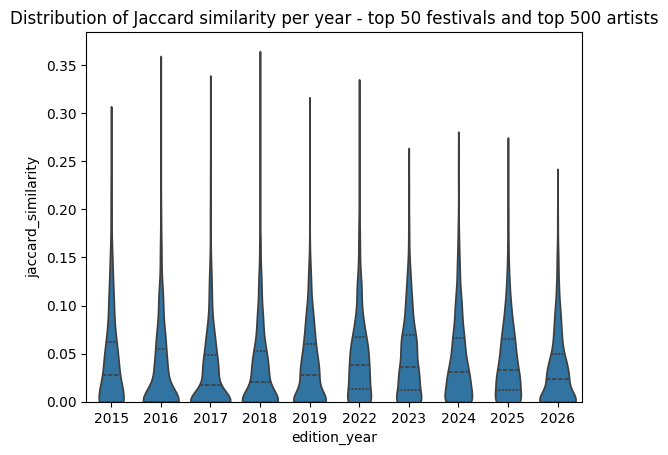

In [24]:
ax = sns.violinplot(df_similarities, x='edition_year', y='jaccard_similarity', inner='quart')
ax.set_title('Distribution of Jaccard similarity per year - top 50 festivals and top 500 artists')
ax.set_ylim(0)
plt.show()

Festivals are actually getting more diverse and unique over the last 4 years

In [25]:
show_similarity(
    festival_id_map["Dekmantel"] + "-2024",
    festival_id_map["Horst"] + "-2024",
    df_lineups=df_lineups,
    festival_name_map=festival_name_map,
    artist_name_map=artist_name_map,
)

Similarity report between 8578965883151947907-2024 - Dekmantel-2024 and 8982369933757010704-2024 - Horst-2024
Jaccard similarity: 0.17
22 artists playing at both, 75 playing only at Dekmantel-2024, 34 playing only at Horst-2024
Intersection         Playing only at Dekmantel-2024    Playing only at Horst-2024
-------------------  --------------------------------  ----------------------------
Jane Fitz            DJ Stingray 313                   Tai Lokun
Call Super           Octave One                        Lola Haro
Aurora Halal         Nelly (NL)                        Fadi Mohem
Eris Drew            Gabrielle Kwarteng                Unai Trotti
Palms Trax           Marcel Dettmann                   Sedef Adasï
Sybil                Hyperaktivist                     Budino
Sandrien             Identified Patient                fka.m4a
Kode9                Amaliah                           Richard Akingbehin
Woody92              Freddy K                          Fais Le Beau
Mama Snak

What if we further limit to the real top artists?

In [26]:
n_artists = 100
top_n_artists = (
    df_lineups.groupby("artist_id")
    .size()
    .sort_values(ascending=False)[:n_artists]
    .index
)

In [27]:
df_lineups = df_lineups[
    (df_lineups['festival_id'].isin(top_n_festivals)) 
    & (df_lineups['artist_id'].isin(top_n_artists))
]

In [28]:
df_lineups['display_name'].unique()

array(['Ben UFO', 'OK Williams', 'Antal', 'Ben Klock', 'Or:la',
       'Dave Harvey', 'Nina Kraviz', 'Jen Cardini', 'John Talabot',
       'Josey Rebelle', 'Lena Willikens', 'Shanti Celeste', 'Call Super',
       'Hunee', 'Blawan', 'Saoirse', 'Roi Perez', 'KI/KI',
       'Pearson Sound', 'Jeff Mills', 'Young Marco', 'Palms Trax',
       'Vladimir Ivkovic', 'Freddy K', 'Dr. Rubinstein', 'Job Jobse',
       'Batu', 'Tama Sumo', 'Suze Ijó', 'Move D', 'Sonja Moonear',
       'Jane Fitz', 'Mall Grab', 'Sedef Adasï', 'FJAAK', 'HAAi',
       'Joy Orbison', 'DJ Nobu', 'DjRUM', 'Craig Richards',
       'Avalon Emerson', 'Prosumer', 'Maceo Plex', 'CARISTA', 'Dr Banana',
       'Eris Drew', 'Gabrielle Kwarteng', 'Sassy J', 'Octo Octa',
       'PARAMIDA', 'DVS1', 'Âme', 'Motor City Drum Ensemble', 'Tom Trago',
       'Mama Snake', 'Helena Hauff', 'SHERELLE', 'Bradley Zero', 'Objekt',
       'Roza Terenzi', 'Vlada', 'Skee Mask', 'Horse Meat Disco',
       'Midland', 'Moxie', 'Peach', 'Nicolas Lutz'

In [29]:
years = sorted(df_lineups['edition_year'].unique())
dfs_similarities = [
    build_df_festival_edition_similarities(
        df_lineups=df_lineups, df_festival_stats=df_festival_stats, edition_year=year
    ) for year in years
]
df_similarities = pd.concat(dfs_similarities)

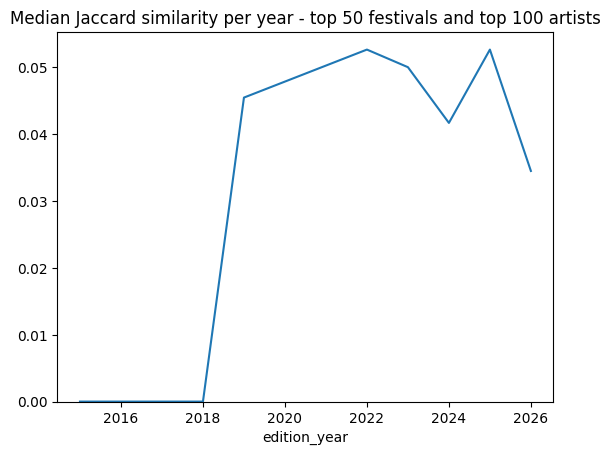

In [30]:
mean_similarities = df_similarities.groupby('edition_year')['jaccard_similarity'].median()
mean_similarities.plot(kind='line', title='Median Jaccard similarity per year - top 50 festivals and top 100 artists')
plt.gca().set_ylim(0)
plt.show()

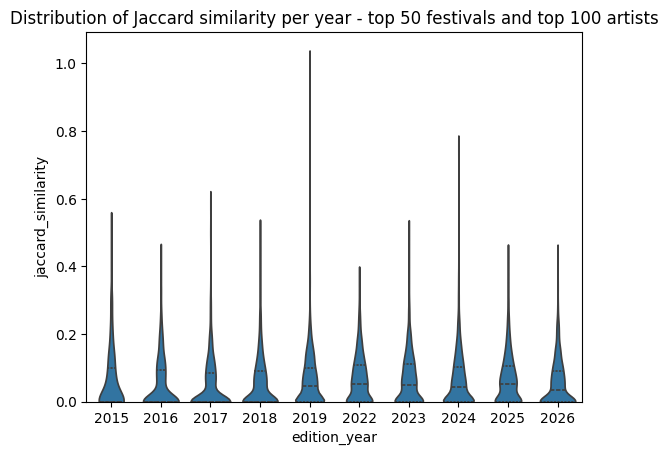

In [31]:
ax = sns.violinplot(df_similarities, x='edition_year', y='jaccard_similarity', inner='quart') 
ax.set_title('Distribution of Jaccard similarity per year - top 50 festivals and top 100 artists')
ax.set_ylim(0)
plt.show()